In [ ]:
print("=== SAVING MODEL AND ARTIFACTS ===")

import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(final_kmeans, '../models/kmeans_model.pkl')
print("K-means model saved!")

joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler saved!")

segment_mapping = {
    0: "Loyal High-Spenders",
    1: "At-Risk Customers", 
    2: "Budget Shoppers"
}
joblib.dump(segment_mapping, '../models/segment_mapping.pkl')
print("Segment mapping saved!")

rfm_clean.to_csv('../data/processed/segmented_customers.csv', index=False)
rfm_clean.to_csv('../data/processed/segmented_customers_with_behavior.csv', index=False)
print("Data saved with behavioral features!")
print("Final segmented data saved!")

print("All model artifacts saved successfully!")
print("Files created:")
print("   - ../models/kmeans_model.pkl")
print("   - ../models/scaler.pkl") 
print("   - ../models/segment_mapping.pkl")
print("   - ../data/processed/final_segmented_data.csv")

=== SAVING MODEL AND ARTIFACTS ===
K-means model saved!
Scaler saved!
Segment mapping saved!
Data saved with behavioral features!
Final segmented data saved!
All model artifacts saved successfully!
Files created:
   - ../models/kmeans_model.pkl
   - ../models/scaler.pkl
   - ../models/segment_mapping.pkl
   - ../data/processed/final_segmented_data.csv


=== CUSTOMER SEGMENTATION WITH BEHAVIORAL FEATURES ===
Currency conversion applied: 2.7 INR per TL

=== CALCULATING BEHAVIORAL FEATURES ===
1. Adding category preferences...
2. Adding payment behavior...
3. Adding cart behavior...
4. Adding time behavior...

=== CALCULATING RFM METRICS ===
Merging all features...
Full dataset with behavioral features: (99457, 15)
Sampled to: (15000, 15) for faster processing

Removing outliers...
After outlier removal: (14715, 15)
Using 11 features for clustering

=== CLUSTERING ANALYSIS ===
Testing k=2...
Testing k=3...
Testing k=4...
Testing k=5...


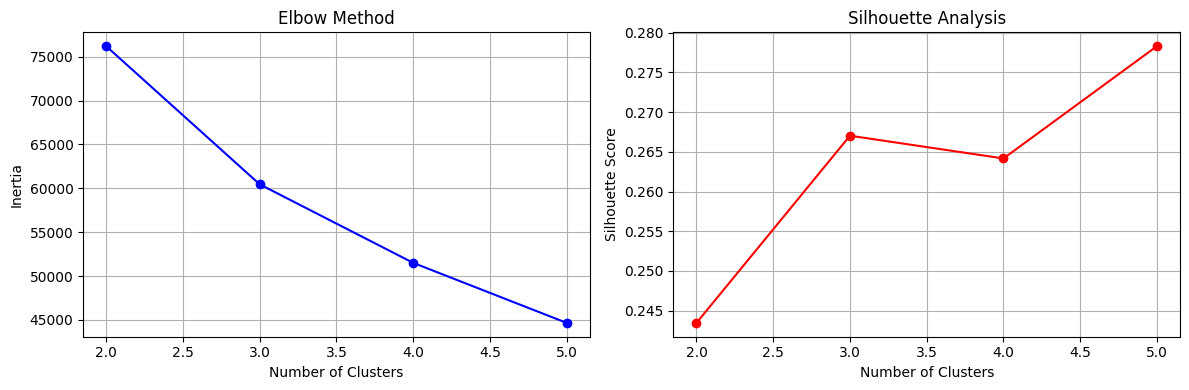

Optimal number of clusters: 5
Silhouette scores: {2: 0.24344797582171288, 3: 0.2670336902234213, 4: 0.26416604028633023, 5: 0.2783160540975368}

Training final model with 5 clusters...
Model training completed!

=== SEGMENT ANALYSIS ===
Total customers analyzed: 14715
Segment 0: 2778 customers (18.9%)
Segment 1: 4497 customers (30.6%)
Segment 2: 776 customers (5.3%)
Segment 3: 4177 customers (28.4%)
Segment 4: 2487 customers (16.9%)

=== ENHANCED SEGMENT PROFILES ===
Basic RFM Metrics:
         recency  frequency  monetary_inr    age
segment                                         
0         392.74        1.0        179.57  43.75
1         399.14        1.0        895.10  43.57
2         392.57        1.0      10078.95  43.60
3         400.38        1.0       3149.61  43.23
4         395.64        1.0        964.41  43.67

Behavioral Metrics:
         category_variety  payment_flexibility  avg_items_per_order  \
segment                                                               
0  

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/raw/customer_shopping_data.csv')

print("=== CUSTOMER SEGMENTATION WITH BEHAVIORAL FEATURES ===")

df['invoice_date'] = pd.to_datetime(df['invoice_date'], format='%d/%m/%Y')

exchange_rate = 2.70
df['price_inr'] = df['price'] * exchange_rate

print(f"Currency conversion applied: {exchange_rate} INR per TL")

print("\n=== CALCULATING BEHAVIORAL FEATURES ===")

print("1. Adding category preferences...")
category_behavior = df.groupby('customer_id')['category'].agg([
    ('category_variety', 'nunique'),
    ('is_fashion_shopper', lambda x: 1 if any(cat in ['Clothing', 'Shoes', 'Cosmetics'] for cat in x) else 0)
]).reset_index()

print("2. Adding payment behavior...")
payment_behavior = df.groupby('customer_id')['payment_method'].agg([
    ('payment_flexibility', 'nunique')
]).reset_index()

print("3. Adding cart behavior...")
cart_behavior = df.groupby('customer_id').agg({
    'quantity': ['mean', 'max'],
    'price_inr': 'mean'
}).reset_index()
cart_behavior.columns = ['customer_id', 'avg_items_per_order', 'max_items_per_order', 'avg_order_value']

print("4. Adding time behavior...")
df['purchase_hour'] = df['invoice_date'].dt.hour
df['day_of_week'] = df['invoice_date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

time_behavior = df.groupby('customer_id').agg({
    'purchase_hour': 'mean',
    'is_weekend': 'mean',
}).reset_index()
time_behavior.columns = ['customer_id', 'preferred_hour', 'weekend_ratio']

print("\n=== CALCULATING RFM METRICS ===")
latest_date = df['invoice_date'].max()

rfm_data = df.groupby('customer_id').agg({
    'invoice_date': lambda x: (latest_date - x.max()).days,
    'invoice_no': 'count', 
    'price_inr': 'sum'
}).reset_index()

rfm_data.columns = ['customer_id', 'recency', 'frequency', 'monetary_inr']

customer_demographics = df[['customer_id', 'gender', 'age', 'shopping_mall']].drop_duplicates()
rfm_full = rfm_data.merge(customer_demographics, on='customer_id', how='left')

print("Merging all features...")
rfm_with_behavior = rfm_full.merge(category_behavior, on='customer_id', how='left')
rfm_with_behavior = rfm_with_behavior.merge(payment_behavior, on='customer_id', how='left')
rfm_with_behavior = rfm_with_behavior.merge(cart_behavior, on='customer_id', how='left')
rfm_with_behavior = rfm_with_behavior.merge(time_behavior, on='customer_id', how='left')

print(f"Full dataset with behavioral features: {rfm_with_behavior.shape}")

sample_size = 15000
if len(rfm_with_behavior) > sample_size:
    rfm_sampled = rfm_with_behavior.sample(n=sample_size, random_state=42)
    print(f"Sampled to: {rfm_sampled.shape} for faster processing")
else:
    rfm_sampled = rfm_with_behavior.copy()

print("\nRemoving outliers...")
def quick_outlier_removal(df, columns):
    clean_df = df.copy()
    for col in columns:
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)
        clean_df = clean_df[(clean_df[col] >= lower) & (clean_df[col] <= upper)]
    return clean_df

feature_columns = [
    'recency', 'frequency', 'monetary_inr',
    'category_variety', 'is_fashion_shopper',
    'payment_flexibility',
    'avg_items_per_order', 'max_items_per_order', 'avg_order_value',
    'preferred_hour', 'weekend_ratio'
]

rfm_clean = quick_outlier_removal(rfm_sampled, feature_columns)
print(f"After outlier removal: {rfm_clean.shape}")

X = rfm_clean[feature_columns]
print(f"Using {len(feature_columns)} features for clustering")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\n=== CLUSTERING ANALYSIS ===")

k_range = [2, 3, 4, 5]
inertia = []
silhouette_scores = []

for k in k_range:
    print(f"Testing k={k}...")
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    cluster_labels = kmeans.fit_predict(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(k_range, inertia, 'bo-')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.grid(True)

ax2.plot(k_range, silhouette_scores, 'ro-')
ax2.set_xlabel('Number of Clusters')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Analysis')
ax2.grid(True)

plt.tight_layout()
plt.show()

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters: {optimal_k}")
print(f"Silhouette scores: {dict(zip(k_range, silhouette_scores))}")

print(f"\nTraining final model with {optimal_k} clusters...")
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm_clean['segment'] = final_kmeans.fit_predict(X_scaled)

print("Model training completed!")

print(f"\n=== SEGMENT ANALYSIS ===")
print(f"Total customers analyzed: {len(rfm_clean)}")

segment_counts = rfm_clean['segment'].value_counts().sort_index()
for segment, count in segment_counts.items():
    percentage = (count / len(rfm_clean)) * 100
    print(f"Segment {segment}: {count} customers ({percentage:.1f}%)")

print(f"\n=== SEGMENT PROFILES ===")
segment_profiles = rfm_clean.groupby('segment').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary_inr': 'mean',
    'age': 'mean',
    'category_variety': 'mean',
    'payment_flexibility': 'mean',
    'avg_items_per_order': 'mean',
    'weekend_ratio': 'mean'
}).round(2)

print("Basic RFM Metrics:")
print(segment_profiles[['recency', 'frequency', 'monetary_inr', 'age']])

print("\nBehavioral Metrics:")
print(segment_profiles[['category_variety', 'payment_flexibility', 'avg_items_per_order', 'weekend_ratio']])

rfm_clean.to_csv('../data/processed/segmented_customers_with_behavior.csv', index=False)
print("\nData saved to '../data/processed/segmented_customers_with_behavior.csv'")

print(f"\n=== BUSINESS INSIGHTS ===")
segment_names = {
    0: "Loyal High-Spenders",
    1: "At-Risk Customers", 
    2: "Budget Shoppers"
}

for segment in range(optimal_k):
    seg_data = rfm_clean[rfm_clean['segment'] == segment]
    name = segment_names.get(segment, f"Segment {segment}")
    
    print(f"\n{name}:")
    print(f"   Customers: {len(seg_data)} ({len(seg_data)/len(rfm_clean)*100:.1f}%)")
    print(f"   Recency: {seg_data['recency'].mean():.0f} days | Spending: Rs{seg_data['monetary_inr'].mean():.0f}")
    print(f"   Category Variety: {seg_data['category_variety'].mean():.1f} categories")
    print(f"   Payment Methods: {seg_data['payment_flexibility'].mean():.1f} types")
    print(f"   Avg Cart Size: {seg_data['avg_items_per_order'].mean():.1f} items")
    print(f"   Weekend Shopping: {seg_data['weekend_ratio'].mean()*100:.1f}%")
    
    if segment == 0:  # High-Spenders
        if seg_data['category_variety'].mean() > 3:
            print("   Strategy: Cross-category premium bundles and VIP events")
        else:
            print("   Strategy: Category-specific loyalty and early access")
            
    elif segment == 1:  # At-Risk
        if seg_data['weekend_ratio'].mean() > 0.5:
            print("   Strategy: Weekend-specific win-back offers")
        else:
            print("   Strategy: Personalized weekday re-engagement campaigns")
            
    else:  # Budget Shoppers
        if seg_data['payment_flexibility'].mean() > 1.5:
            print("   Strategy: Multiple payment method promotions")
        else:
            print("   Strategy: Payment-specific loyalty rewards")

print(f"\nANALYSIS COMPLETE! Ready for dashboard creation.")

print("\n=== SAVING MODEL AND ARTIFACTS ===")

import joblib
import os

os.makedirs('../models', exist_ok=True)

joblib.dump(final_kmeans, '../models/kmeans_model.pkl')
print("K-means model saved!")

joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler saved!")

segment_mapping = {
    0: "Loyal High-Spenders",
    1: "At-Risk Customers", 
    2: "Budget Shoppers"
}
joblib.dump(segment_mapping, '../models/segment_mapping.pkl')
print("Segment mapping saved!")

print("All model artifacts saved successfully!")
print("Files created:")
print("   - ../models/kmeans_model.pkl")
print("   - ../models/scaler.pkl") 
print("   - ../models/segment_mapping.pkl")
print("   - ../data/processed/segmented_customers_with_behavior.csv")